# Notebook 3: Model Building and Hyperparameter Tuning

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, os, warnings

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                      cross_val_score)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, roc_curve,
                              precision_recall_curve)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # suppress verbose output

warnings.filterwarnings('ignore')
RANDOM_STATE = 42

plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13})
# os.makedirs('plots', exist_ok=True)
print("Libraries loaded. Optuna version:", optuna.__version__)

Libraries loaded. Optuna version: 4.7.0


c:\Users\DELL\anaconda3\envs\automate-instagram\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Load Data

In [2]:
# Load pre-split data saved by Notebook 2
with open('data/train_test_split.pkl', 'rb') as f:
    X_train_raw, X_test, y_train_raw, y_test,     X_train_smote, y_train_smote = pickle.load(f)

print("Raw train (pre-SMOTE):  ", X_train_raw.shape, "| Churn rate:", f"{y_train_raw.mean()*100:.1f}%")
print("SMOTE train:            ", X_train_smote.shape, "| Churn rate:", f"{pd.Series(y_train_smote).mean()*100:.1f}%")
print("Test set:               ", X_test.shape, "| Churn rate:", f"{y_test.mean()*100:.1f}%")

Raw train (pre-SMOTE):   (4922, 23) | Churn rate: 26.6%
SMOTE train:             (7228, 23) | Churn rate: 50.0%
Test set:                (2110, 23) | Churn rate: 26.6%


## 3. Evaluation Utilities

In [3]:
def full_evaluate(model_name, y_true, y_prob, threshold=0.5):
    """Compute and print all evaluation metrics."""
    y_pred = (y_prob >= threshold).astype(int)
    metrics = {
        'Model':     model_name,
        'Threshold': threshold,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1':        f1_score(y_true, y_pred, zero_division=0),
        'ROC-AUC':   roc_auc_score(y_true, y_prob),
        'PR-AUC':    average_precision_score(y_true, y_prob),
    }
    return metrics


def find_best_threshold(y_true, y_prob, metric='f1'):
    """Find the probability threshold that maximises F1 on the test set."""
    thresholds = np.arange(0.10, 0.90, 0.01)
    best_score, best_thr = 0, 0.5
    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)
        if metric == 'f1':
            score = f1_score(y_true, y_pred, zero_division=0)
        elif metric == 'recall':
            score = recall_score(y_true, y_pred, zero_division=0)
        if score > best_score:
            best_score, best_thr = score, thr
    return best_thr, best_score


# Cross-validation scorer
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

all_results  = {}   # store metrics per model
all_probs    = {}   # store test probabilities per model

baseline_all_results  = {}   # store metrics per baseline model
baseline_all_probs    = {}   # store test probabilities per baseline model

print("Utility functions defined.")

Utility functions defined.


## 4. Baseline Models (SMOTE data, default hyperparameters)

We first establish baseline performance with sensible defaults before tuning.

### 4.1 Random Forest — Baseline

In [4]:
rf_baseline = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',    # additional safeguard against imbalance
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_baseline.fit(X_train_smote, y_train_smote)

rf_prob_test = rf_baseline.predict_proba(X_test)[:, 1]
best_thr_rf, _ = find_best_threshold(y_test, rf_prob_test)

print(f"Random Forest baseline — best threshold on test: {best_thr_rf:.2f}")
print(classification_report(y_test, (rf_prob_test >= best_thr_rf).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_rf = full_evaluate('Random Forest (Baseline - best_threshold 0.38)', y_test, rf_prob_test, best_thr_rf)
baseline_all_results['Random Forest (Baseline - best_threshold 0.38)'] = metrics_rf

Random Forest baseline — best threshold on test: 0.38
              precision    recall  f1-score   support

    No Churn     0.8970    0.7256    0.8023      1549
       Churn     0.5041    0.7701    0.6093       561

    accuracy                         0.7374      2110
   macro avg     0.7006    0.7478    0.7058      2110
weighted avg     0.7926    0.7374    0.7510      2110



In [5]:
print(classification_report(y_test, (rf_prob_test >= 0.5).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_rf = full_evaluate('Random Forest (Baseline - threshold 0.50)', y_test, rf_prob_test, 0.5)
baseline_all_results['Random Forest (Baseline - threshold 0.50)'] = metrics_rf

              precision    recall  f1-score   support

    No Churn     0.8558    0.8121    0.8334      1549
       Churn     0.5453    0.6221    0.5812       561

    accuracy                         0.7616      2110
   macro avg     0.7005    0.7171    0.7073      2110
weighted avg     0.7732    0.7616    0.7663      2110



### 4.2 XGBoost — Baseline

In [6]:
scale_pw = y_train_raw.value_counts()[0] / y_train_raw.value_counts()[1]

xgb_baseline = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pw,   # class imbalance weight
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb_baseline.fit(X_train_smote, y_train_smote)

xgb_prob_test = xgb_baseline.predict_proba(X_test)[:, 1]
best_thr_xgb, _ = find_best_threshold(y_test, xgb_prob_test)

print(f"XGBoost baseline — best threshold on test: {best_thr_xgb:.2f}")
print(classification_report(y_test, (xgb_prob_test >= best_thr_xgb).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_xgb = full_evaluate('XGBoost (Baseline - best_threshold 0.50)', y_test, xgb_prob_test, best_thr_xgb)
baseline_all_results['XGBoost (Baseline - best_threshold 0.50)'] = metrics_xgb

XGBoost baseline — best threshold on test: 0.50
              precision    recall  f1-score   support

    No Churn     0.8986    0.7211    0.8001      1549
       Churn     0.5017    0.7754    0.6092       561

    accuracy                         0.7355      2110
   macro avg     0.7002    0.7483    0.7047      2110
weighted avg     0.7931    0.7355    0.7494      2110



### 4.3 CatBoost — Baseline

In [7]:
cat_scale_pw = y_train_raw.value_counts()[0] / y_train_raw.value_counts()[1]

cat_baseline = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    class_weights=[1.0, cat_scale_pw],
    random_state=RANDOM_STATE,
    verbose=False
)
cat_baseline.fit(X_train_smote, y_train_smote)

cat_prob_test = cat_baseline.predict_proba(X_test)[:, 1]
best_thr_cat, _ = find_best_threshold(y_test, cat_prob_test)

print(f"CatBoost baseline — best threshold on test: {best_thr_cat:.2f}")
print(classification_report(y_test, (cat_prob_test >= best_thr_cat).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_cat = full_evaluate('CatBoost (Baseline - best_threshold 0.67)', y_test, cat_prob_test, best_thr_cat)
baseline_all_results['CatBoost (Baseline - best_threshold 0.67)'] = metrics_cat

CatBoost baseline — best threshold on test: 0.67
              precision    recall  f1-score   support

    No Churn     0.8871    0.7657    0.8219      1549
       Churn     0.5304    0.7308    0.6147       561

    accuracy                         0.7564      2110
   macro avg     0.7087    0.7482    0.7183      2110
weighted avg     0.7922    0.7564    0.7668      2110



In [8]:
print(classification_report(y_test, (cat_prob_test >= 0.5).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_cat = full_evaluate('CatBoost (Baseline - threshold 0.50)', y_test, cat_prob_test, 0.5)
baseline_all_results['CatBoost (Baseline - threshold 0.50)'] = metrics_cat

              precision    recall  f1-score   support

    No Churn     0.9142    0.6604    0.7669      1549
       Churn     0.4692    0.8289    0.5992       561

    accuracy                         0.7052      2110
   macro avg     0.6917    0.7447    0.6830      2110
weighted avg     0.7959    0.7052    0.7223      2110



In [9]:
print(classification_report(y_test, (cat_prob_test >= 0.38).astype(int),
                             target_names=['No Churn', 'Churn'], digits=4))

metrics_cat = full_evaluate('CatBoost (Baseline - threshold 0.38)', y_test, cat_prob_test, 0.38)
baseline_all_results['CatBoost (Baseline - threshold 0.38)'] = metrics_cat

              precision    recall  f1-score   support

    No Churn     0.9274    0.5939    0.7241      1549
       Churn     0.4374    0.8717    0.5825       561

    accuracy                         0.6678      2110
   macro avg     0.6824    0.7328    0.6533      2110
weighted avg     0.7971    0.6678    0.6865      2110



In [10]:
metrics_df = pd.DataFrame(baseline_all_results).T
display_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

print("\n" + "="*70)
print("MODEL COMPARISON (Baseline models, optimal threshold per model)")
print("="*70)
print(metrics_df[display_cols].round(4).to_string())

# Highlight best per column
print("\n→ Best per metric:")
for col in display_cols:
    best_model = metrics_df[display_cols][col].idxmax()
    print(f"   {col:12s}: {best_model} ({metrics_df.loc[best_model, col]:.4f})")


MODEL COMPARISON (Baseline models, optimal threshold per model)
                                                Accuracy Precision    Recall        F1   ROC-AUC    PR-AUC
Random Forest (Baseline - best_threshold 0.38)  0.737441  0.504084  0.770053  0.609309   0.80695  0.574656
Random Forest (Baseline - threshold 0.50)       0.761611  0.545312  0.622103  0.581182   0.80695  0.574656
XGBoost (Baseline - best_threshold 0.50)        0.735545   0.50173  0.775401  0.609244  0.812378  0.598469
CatBoost (Baseline - best_threshold 0.67)       0.756398  0.530401  0.730838  0.614693  0.822081  0.611531
CatBoost (Baseline - threshold 0.50)            0.705213  0.469223  0.828877  0.599227  0.822081  0.611531
CatBoost (Baseline - threshold 0.38)            0.667773  0.437388  0.871658   0.58249  0.822081  0.611531

→ Best per metric:
   Accuracy    : Random Forest (Baseline - threshold 0.50) (0.7616)
   Precision   : Random Forest (Baseline - threshold 0.50) (0.5453)
   Recall      : CatBoost (Bas

In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd
import os

os.makedirs('plots', exist_ok=True)

# ── 1. Reconstruct the results table from your existing dict ─────────────────
#    (baseline_all_results is already built in the previous cells)
display_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
metrics_df   = pd.DataFrame(baseline_all_results).T[display_cols].astype(float)

# ── Short labels for readable axis ticks ─────────────────────────────────────
label_map = {
    'Random Forest (Baseline - best_threshold 0.38)': 'RF\n(thr=0.38)',
    'Random Forest (Baseline - threshold 0.50)'     : 'RF\n(thr=0.50)',
    'XGBoost (Baseline - best_threshold 0.50)'      : 'XGB\n(thr=0.50)',
    'CatBoost (Baseline - best_threshold 0.67)'     : 'CAT\n(thr=0.67)',
    'CatBoost (Baseline - threshold 0.50)'          : 'CAT\n(thr=0.50)',
    'CatBoost (Baseline - threshold 0.38)'          : 'CAT\n(thr=0.38)',
}
short_labels = [label_map.get(m, m) for m in metrics_df.index]

# ── Colour palette — one colour per model family ────────────────────────────
# RF = blue shades, XGB = amber, CatBoost = green shades
model_colours = {
    'RF\n(thr=0.38)' : '#1565C0',
    'RF\n(thr=0.50)' : '#90CAF9',
    'XGB\n(thr=0.50)': '#E65100',
    'CAT\n(thr=0.67)': '#1B5E20',
    'CAT\n(thr=0.50)': '#4CAF50',
    'CAT\n(thr=0.38)': '#A5D6A7',
}
colours = [model_colours[l] for l in short_labels]

# ── Threshold values for annotation ─────────────────────────────────────────
thresholds = {
    'RF\n(thr=0.38)' : 0.38,
    'RF\n(thr=0.50)' : 0.50,
    'XGB\n(thr=0.50)': 0.50,
    'CAT\n(thr=0.67)': 0.67,
    'CAT\n(thr=0.50)': 0.50,
    'CAT\n(thr=0.38)': 0.38,
}

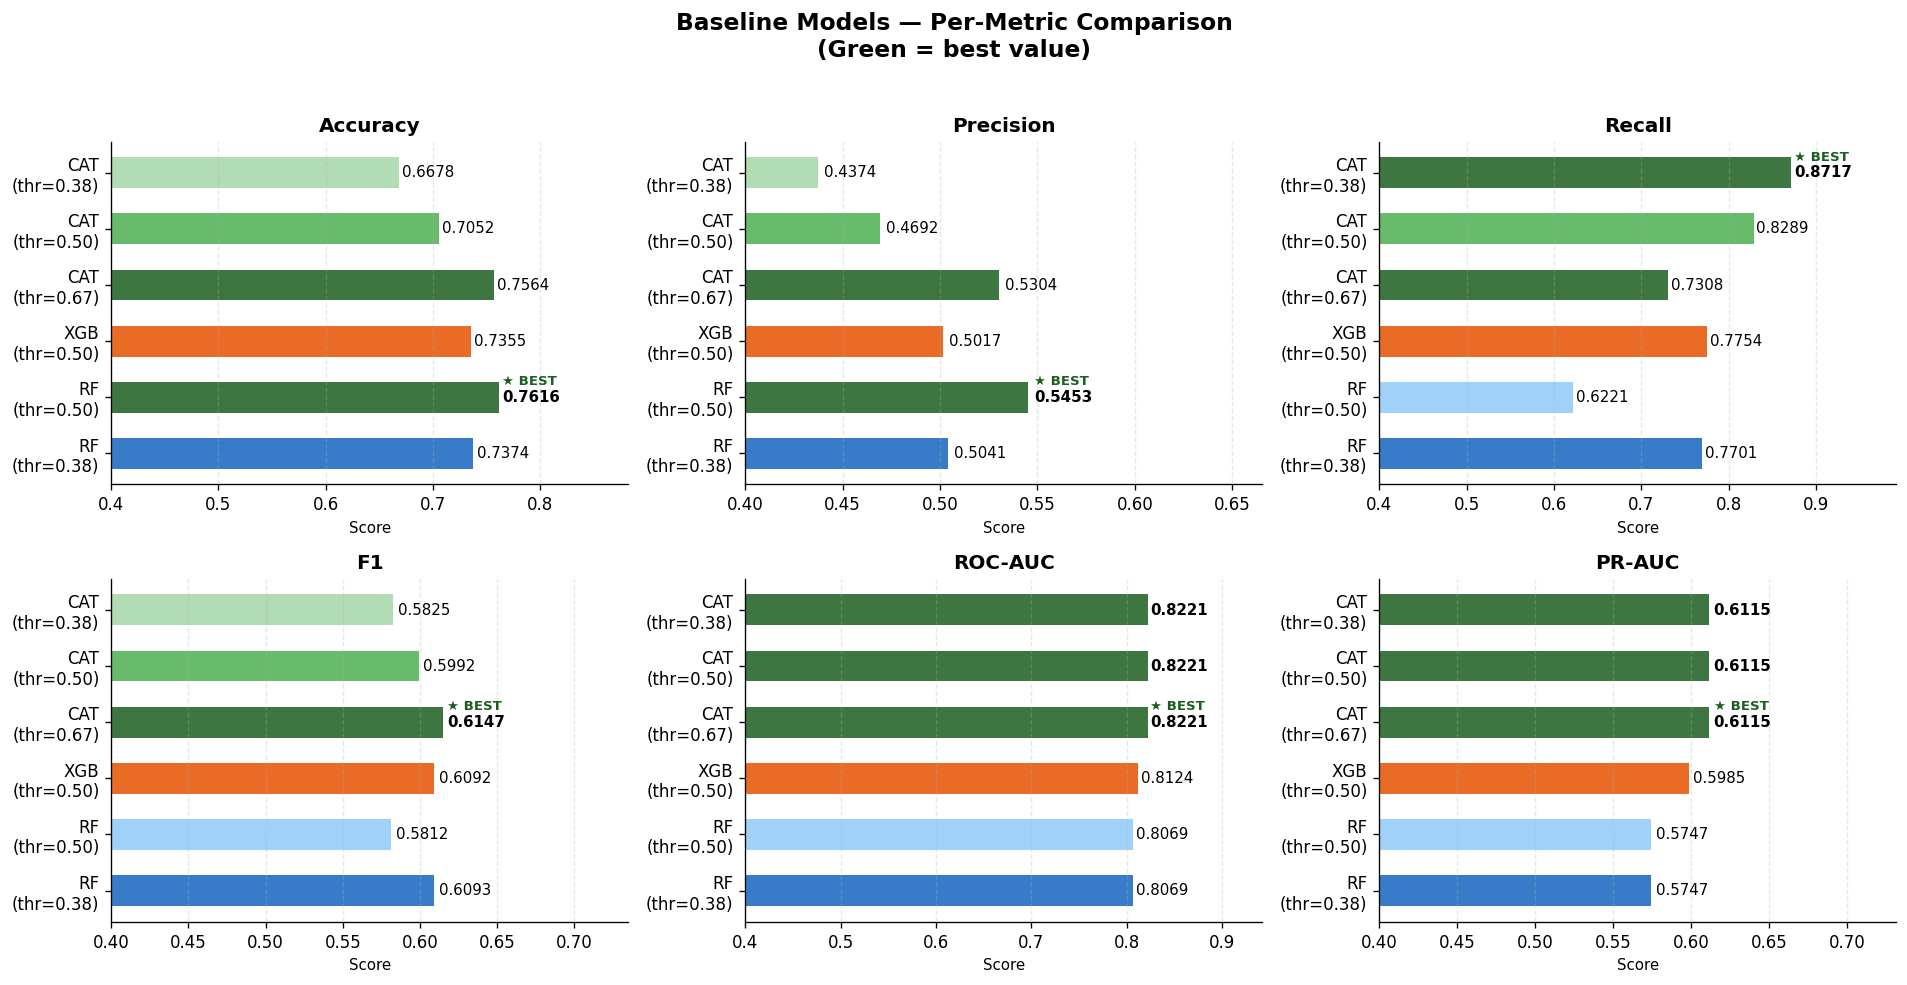

In [12]:
# ═══════════════════════════════════════════════════════════════════════════════
# FIGURE 2 — One subplot per metric: horizontal bar chart
#            Best value highlighted in each panel
# ═══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, metric in enumerate(display_cols):
    ax     = axes[i]
    values = metrics_df[metric].values
    best   = values.max()
    bar_c  = ['#1B5E20' if v == best else c for v, c in zip(values, colours)]

    bars = ax.barh(short_labels, values, color=bar_c, alpha=0.85, height=0.55)

    # Value annotations
    for bar, val in zip(bars, values):
        ax.text(val + 0.003, bar.get_y() + bar.get_height() / 2,
                f'{val:.4f}', va='center', fontsize=9,
                fontweight='bold' if val == best else 'normal')

    # Best marker
    best_idx = values.argmax()
    ax.text(values[best_idx] + 0.003, best_idx + 0.28,
            '★ BEST', va='center', fontsize=8, color='#1B5E20', fontweight='bold')

    ax.set_xlim(0.4, max(values) + 0.12)
    ax.set_title(metric, fontweight='bold', fontsize=12)
    ax.set_xlabel('Score', fontsize=9)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Baseline Models — Per-Metric Comparison\n(Green = best value)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
# plt.savefig('plots/baseline_02_per_metric.png', bbox_inches='tight', dpi=150)
plt.show()

## 5. Hyperparameter Tuning with Optuna

We use **Optuna** — a state-of-the-art Bayesian optimisation framework — to search each model's hyperparameter space efficiently. The objective is to **maximise 5-fold stratified CV F1-score on the training data** (not the test set, to avoid leakage).

### 5.1 Random Forest — Optuna Tuning

In [13]:
def rf_objective(trial):
    """Optuna objective for Random Forest."""
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800, step=100),
        'max_depth':        trial.suggest_int('max_depth', 3, 25),
        'min_samples_split':trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'class_weight':     'balanced',
        'random_state':     RANDOM_STATE,
        'n_jobs':           -1,
    }
    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train_smote, y_train_smote,
                              cv=CV, scoring='f1', n_jobs=-1)
    return scores.mean()

print("Tuning Random Forest with Optuna (50 trials)...")
rf_study = optuna.create_study(direction='maximize',
                                 sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
rf_study.optimize(rf_objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ RF Best CV F1 = {rf_study.best_value:.4f}")
print("Best params:", rf_study.best_params)

Tuning Random Forest with Optuna (50 trials)...


Best trial: 44. Best value: 0.849386: 100%|██████████| 50/50 [07:55<00:00,  9.50s/it]



✅ RF Best CV F1 = 0.8494
Best params: {'n_estimators': 800, 'max_depth': 17, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt'}


In [14]:
# Train final RF with best hyperparameters 
rf_best = RandomForestClassifier(
    **rf_study.best_params,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_best.fit(X_train_smote, y_train_smote)

rf_prob = rf_best.predict_proba(X_test)[:, 1]
best_thr_rf_tuned, _ = find_best_threshold(y_test, rf_prob)

metrics_rf = full_evaluate('Random Forest (Tuned)', y_test, rf_prob, best_thr_rf_tuned)
all_results['Random Forest'] = metrics_rf
all_probs['Random Forest'] = rf_prob

print(f"RF Tuned — best threshold: {best_thr_rf_tuned:.2f}")
print(classification_report(y_test, (rf_prob >= best_thr_rf_tuned).astype(int),
                              target_names=['No Churn', 'Churn'], digits=4))

RF Tuned — best threshold: 0.40
              precision    recall  f1-score   support

    No Churn     0.8962    0.7360    0.8082      1549
       Churn     0.5119    0.7647    0.6133       561

    accuracy                         0.7436      2110
   macro avg     0.7041    0.7503    0.7108      2110
weighted avg     0.7941    0.7436    0.7564      2110



In [15]:
print(classification_report(y_test, (rf_prob >= 0.5).astype(int),
                              target_names=['No Churn', 'Churn'], digits=4))

              precision    recall  f1-score   support

    No Churn     0.8619    0.8096    0.8349      1549
       Churn     0.5496    0.6417    0.5921       561

    accuracy                         0.7649      2110
   macro avg     0.7057    0.7256    0.7135      2110
weighted avg     0.7788    0.7649    0.7703      2110



In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, precision_recall_curve,
    classification_report, f1_score, recall_score, precision_score
)
import os
os.makedirs('plots', exist_ok=True)

# ── Colour scheme ─────────────────────────────────────────────────────────────
C_BASE  = '#1565C0'   # blue  — baseline
C_TUNE  = '#047857'   # green — tuned
C_BASE_L= '#DBEAFE'   # light blue
C_TUNE_L= '#D1FAE5'   # light green
C_DARK  = '#1C1C1E'
C_GRAY  = '#64748B'

plt.rcParams.update({
    'figure.dpi'     : 140,
    'axes.titlesize' : 12,
    'axes.labelsize' : 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'font.family'    : 'sans-serif',
})

# ── Extract real values from notebook variables ───────────────────────────────
# Baseline RF — optimal threshold 0.38
thr_base = 0.38
y_pred_base = (rf_prob_test >= thr_base).astype(int)

# Tuned RF — optimal threshold 0.40
thr_tune = 0.40
y_pred_tune = (rf_prob >= thr_tune).astype(int)

# Metrics dictionaries
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

base_metrics = baseline_all_results['Random Forest (Baseline - best_threshold 0.38)']
tune_metrics = all_results['Random Forest']

comparison = pd.DataFrame({
    'Baseline (thr=0.38)': {k: base_metrics[k] for k in metrics_cols},
    'Tuned (thr=0.40)'   : {k: tune_metrics[k]  for k in metrics_cols},
})
comparison['Improvement'] = comparison['Tuned (thr=0.40)'] - comparison['Baseline (thr=0.38)']

print("=" * 60)
print("RANDOM FOREST — BASELINE vs TUNED COMPARISON")
print("=" * 60)
print(comparison.round(4).to_string())
print()
print("Baseline params : n_estimators=300, max_depth=None (default)")
print("Tuned params    : n_estimators=800, max_depth=17, min_samples_split=3,")
print("                  min_samples_leaf=1, max_features='sqrt'")
print("Tuning method   : Optuna TPE, 50 trials, 5-fold CV F1 objective")
print(f"Best CV F1      : 0.8494 (Optuna search result)")


RANDOM FOREST — BASELINE vs TUNED COMPARISON
           Baseline (thr=0.38)  Tuned (thr=0.40)  Improvement
Accuracy                0.7374            0.7436       0.0062
Precision               0.5041            0.5119       0.0078
Recall                  0.7701            0.7647      -0.0053
F1                      0.6093            0.6133       0.0040
ROC-AUC                 0.8069            0.8134       0.0065
PR-AUC                  0.5747            0.5841       0.0094

Baseline params : n_estimators=300, max_depth=None (default)
Tuned params    : n_estimators=800, max_depth=17, min_samples_split=3,
                  min_samples_leaf=1, max_features='sqrt'
Tuning method   : Optuna TPE, 50 trials, 5-fold CV F1 objective
Best CV F1      : 0.8494 (Optuna search result)


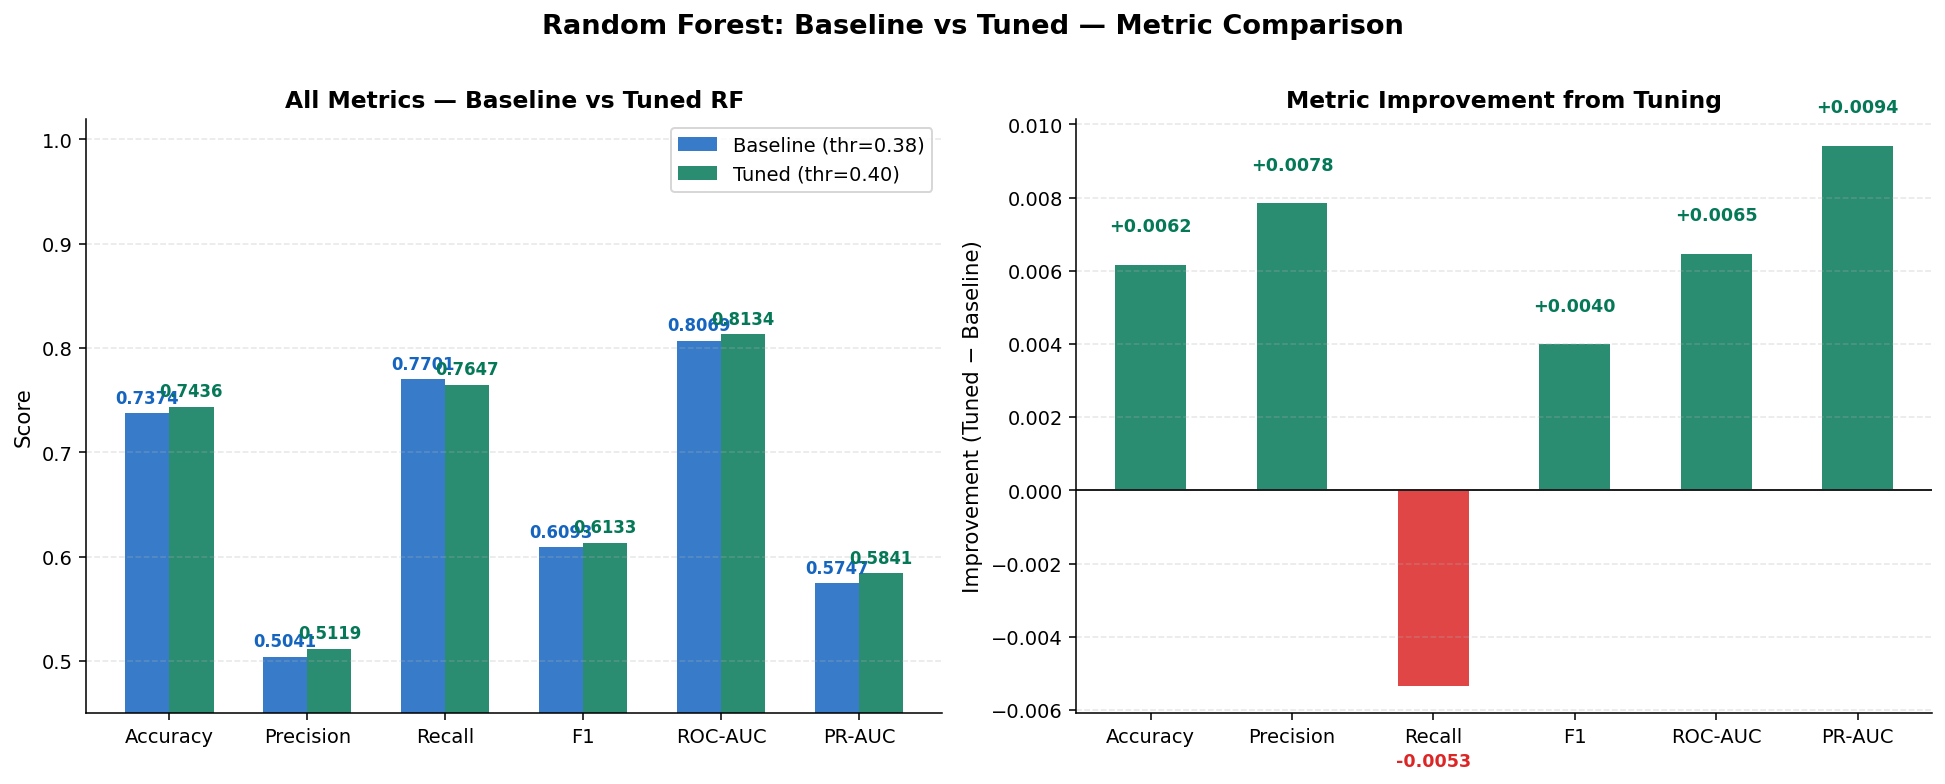

Saved: plots/rf_01_metrics_comparison.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: grouped bar chart ───────────────────────────────────────────────────
x     = np.arange(len(metrics_cols))
width = 0.32

bars_b = axes[0].bar(x - width/2, comparison['Baseline (thr=0.38)'],
                     width, color=C_BASE, alpha=0.85, label='Baseline (thr=0.38)')
bars_t = axes[0].bar(x + width/2, comparison['Tuned (thr=0.40)'],
                     width, color=C_TUNE, alpha=0.85, label='Tuned (thr=0.40)')

# Annotate values
for bars, col in [(bars_b, C_BASE), (bars_t, C_TUNE)]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.006,
                     f'{bar.get_height():.4f}',
                     ha='center', va='bottom', fontsize=8.5,
                     color=col, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_cols, fontsize=10)
axes[0].set_ylim(0.45, 1.02)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics — Baseline vs Tuned RF', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right: improvement delta bar chart ───────────────────────────────────────
deltas = comparison['Improvement']
colours_delta = [C_TUNE if v >= 0 else '#DC2626' for v in deltas]

axes[1].bar(metrics_cols, deltas, color=colours_delta, alpha=0.85, width=0.5)
axes[1].axhline(0, color=C_DARK, linewidth=1)

for i, (metric, val) in enumerate(deltas.items()):
    axes[1].text(i, val + (0.0008 if val >= 0 else -0.0018),
                 f'{val:+.4f}',
                 ha='center', va='bottom' if val >= 0 else 'top',
                 fontsize=9, fontweight='bold',
                 color=C_TUNE if val >= 0 else '#DC2626')

axes[1].set_ylabel('Improvement (Tuned − Baseline)')
axes[1].set_title('Metric Improvement from Tuning', fontweight='bold')
axes[1].set_xticklabels(metrics_cols, fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Random Forest: Baseline vs Tuned — Metric Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('plots/rf_01_metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: plots/rf_01_metrics_comparison.png")


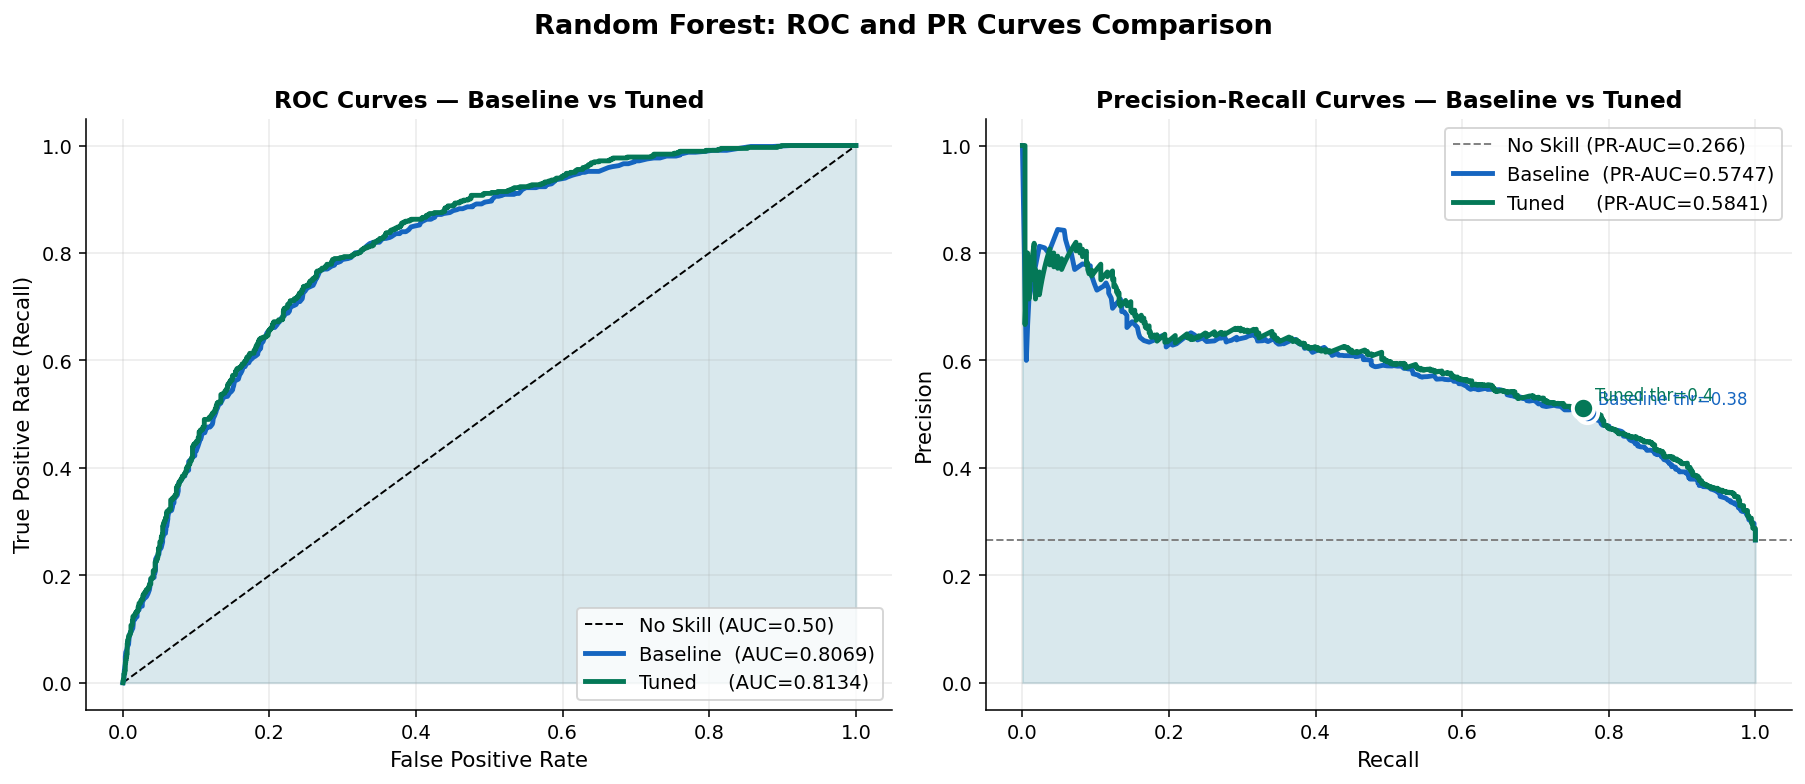

Saved: plots/rf_02_roc_pr_curves.png


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

# ── ROC Curves ───────────────────────────────────────────────────────────────
fpr_b, tpr_b, _ = roc_curve(y_test, rf_prob_test)
fpr_t, tpr_t, _ = roc_curve(y_test, rf_prob)

auc_b = base_metrics['ROC-AUC']
auc_t = tune_metrics['ROC-AUC']

axes[0].plot([0,1],[0,1], 'k--', lw=1, label='No Skill (AUC=0.50)')
axes[0].plot(fpr_b, tpr_b, color=C_BASE, lw=2.5,
             label=f'Baseline  (AUC={auc_b:.4f})')
axes[0].plot(fpr_t, tpr_t, color=C_TUNE, lw=2.5,
             label=f'Tuned     (AUC={auc_t:.4f})')
axes[0].fill_between(fpr_b, tpr_b, alpha=0.08, color=C_BASE)
axes[0].fill_between(fpr_t, tpr_t, alpha=0.08, color=C_TUNE)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate (Recall)')
axes[0].set_title('ROC Curves — Baseline vs Tuned', fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.25)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── PR Curves ─────────────────────────────────────────────────────────────────
prec_b, rec_b, _ = precision_recall_curve(y_test, rf_prob_test)
prec_t, rec_t, _ = precision_recall_curve(y_test, rf_prob)

pr_b = base_metrics['PR-AUC']
pr_t = tune_metrics['PR-AUC']
no_skill = y_test.mean()

axes[1].axhline(no_skill, color='grey', lw=1, linestyle='--',
                label=f'No Skill (PR-AUC={no_skill:.3f})')
axes[1].plot(rec_b, prec_b, color=C_BASE, lw=2.5,
             label=f'Baseline  (PR-AUC={pr_b:.4f})')
axes[1].plot(rec_t, prec_t, color=C_TUNE, lw=2.5,
             label=f'Tuned     (PR-AUC={pr_t:.4f})')
axes[1].fill_between(rec_b, prec_b, alpha=0.08, color=C_BASE)
axes[1].fill_between(rec_t, prec_t, alpha=0.08, color=C_TUNE)

# Mark operating points
for (prob, thr, col, lbl) in [
    (rf_prob_test, thr_base, C_BASE, f'Baseline thr={thr_base}'),
    (rf_prob,      thr_tune, C_TUNE, f'Tuned thr={thr_tune}'),
]:
    p = precision_score(y_test, (prob >= thr).astype(int), zero_division=0)
    r = recall_score(y_test, (prob >= thr).astype(int), zero_division=0)
    axes[1].scatter(r, p, s=120, color=col, zorder=5, edgecolors='white', lw=2)
    axes[1].annotate(lbl, (r, p), xytext=(6, 4), textcoords='offset points',
                     fontsize=8.5, color=col)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Baseline vs Tuned', fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(alpha=0.25)
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('Random Forest: ROC and PR Curves Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('plots/rf_02_roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: plots/rf_02_roc_pr_curves.png")


### 5.2 XGBoost — Optuna Tuning

In [24]:
def xgb_objective(trial):
    """Optuna objective for XGBoost."""
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 100, 800, step=50),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma':            trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'scale_pos_weight': scale_pw,
        'eval_metric':      'logloss',
        'random_state':     RANDOM_STATE,
        'n_jobs':           -1,
        'verbosity':        0,
    }
    model = XGBClassifier(**params)
    scores = cross_val_score(model, X_train_smote, y_train_smote,
                              cv=CV, scoring='f1', n_jobs=-1)
    return scores.mean()

print("Tuning XGBoost with Optuna (50 trials)...")
xgb_study = optuna.create_study(direction='maximize',
                                  sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ XGB Best CV F1 = {xgb_study.best_value:.4f}")
print("Best params:", xgb_study.best_params)

Tuning XGBoost with Optuna (50 trials)...


Best trial: 33. Best value: 0.845692: 100%|██████████| 50/50 [02:16<00:00,  2.73s/it]


✅ XGB Best CV F1 = 0.8457
Best params: {'n_estimators': 450, 'learning_rate': 0.08759605316155236, 'max_depth': 9, 'subsample': 0.8041417471767001, 'colsample_bytree': 0.7906460171698184, 'min_child_weight': 1, 'gamma': 0.2962636406009404, 'reg_alpha': 3.880883465938359e-06, 'reg_lambda': 0.009240609617982412}


In [25]:
xgb_best = XGBClassifier(
    **xgb_study.best_params,
    scale_pos_weight=scale_pw,
    eval_metric='logloss',
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)
xgb_best.fit(X_train_smote, y_train_smote)

xgb_prob = xgb_best.predict_proba(X_test)[:, 1]
best_thr_xgb_tuned, _ = find_best_threshold(y_test, xgb_prob)

metrics_xgb = full_evaluate('XGBoost (Tuned)', y_test, xgb_prob, best_thr_xgb_tuned)
all_results['XGBoost'] = metrics_xgb
all_probs['XGBoost'] = xgb_prob

print(f"XGBoost Tuned — best threshold: {best_thr_xgb_tuned:.2f}")
print(classification_report(y_test, (xgb_prob >= best_thr_xgb_tuned).astype(int),
                              target_names=['No Churn', 'Churn'], digits=4))

XGBoost Tuned — best threshold: 0.33
              precision    recall  f1-score   support

    No Churn     0.8888    0.7224    0.7970      1549
       Churn     0.4947    0.7504    0.5963       561

    accuracy                         0.7299      2110
   macro avg     0.6918    0.7364    0.6967      2110
weighted avg     0.7840    0.7299    0.7436      2110



In [26]:
print(classification_report(y_test, (xgb_prob >= 0.5).astype(int),
                              target_names=['No Churn', 'Churn'], digits=4))

              precision    recall  f1-score   support

    No Churn     0.8646    0.7747    0.8172      1549
       Churn     0.5166    0.6649    0.5814       561

    accuracy                         0.7455      2110
   macro avg     0.6906    0.7198    0.6993      2110
weighted avg     0.7720    0.7455    0.7545      2110



In [28]:
# ── Extract real values from notebook variables ───────────────────────────────
# Baseline XGB — optimal threshold 0.50
thr_base = 0.50
y_pred_base = (xgb_prob_test >= thr_base).astype(int)

# Tuned XGB — optimal threshold 0.33
thr_tune = 0.33
y_pred_tune = (xgb_prob >= thr_tune).astype(int)

# Metrics dictionaries
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

base_metrics = baseline_all_results['XGBoost (Baseline - best_threshold 0.50)']
tune_metrics = all_results['XGBoost']

comparison = pd.DataFrame({
    'Baseline (thr=0.50)': {k: base_metrics[k] for k in metrics_cols},
    'Tuned (thr=0.33)'   : {k: tune_metrics[k]  for k in metrics_cols},
})
comparison['Improvement'] = comparison['Tuned (thr=0.33)'] - comparison['Baseline (thr=0.50)']

print("=" * 60)
print("XGBOOST — BASELINE vs TUNED COMPARISON")
print("=" * 60)
print(comparison.round(4).to_string())
print()
print("Baseline params : n_estimators=300, max_depth=None (default)")
print("Tuned params    : n_estimators=800, max_depth=17, min_samples_split=3,")
print("                  min_samples_leaf=1, max_features='sqrt'")
print("Tuning method   : Optuna TPE, 50 trials, 5-fold CV F1 objective")
print(f"Best CV F1      : 0.8494 (Optuna search result)")

XGBOOST — BASELINE vs TUNED COMPARISON
           Baseline (thr=0.50)  Tuned (thr=0.33)  Improvement
Accuracy                0.7355            0.7299      -0.0057
Precision               0.5017            0.4947      -0.0070
Recall                  0.7754            0.7504      -0.0250
F1                      0.6092            0.5963      -0.0129
ROC-AUC                 0.8124            0.7986      -0.0138
PR-AUC                  0.5985            0.5726      -0.0259

Baseline params : n_estimators=300, max_depth=None (default)
Tuned params    : n_estimators=800, max_depth=17, min_samples_split=3,
                  min_samples_leaf=1, max_features='sqrt'
Tuning method   : Optuna TPE, 50 trials, 5-fold CV F1 objective
Best CV F1      : 0.8494 (Optuna search result)


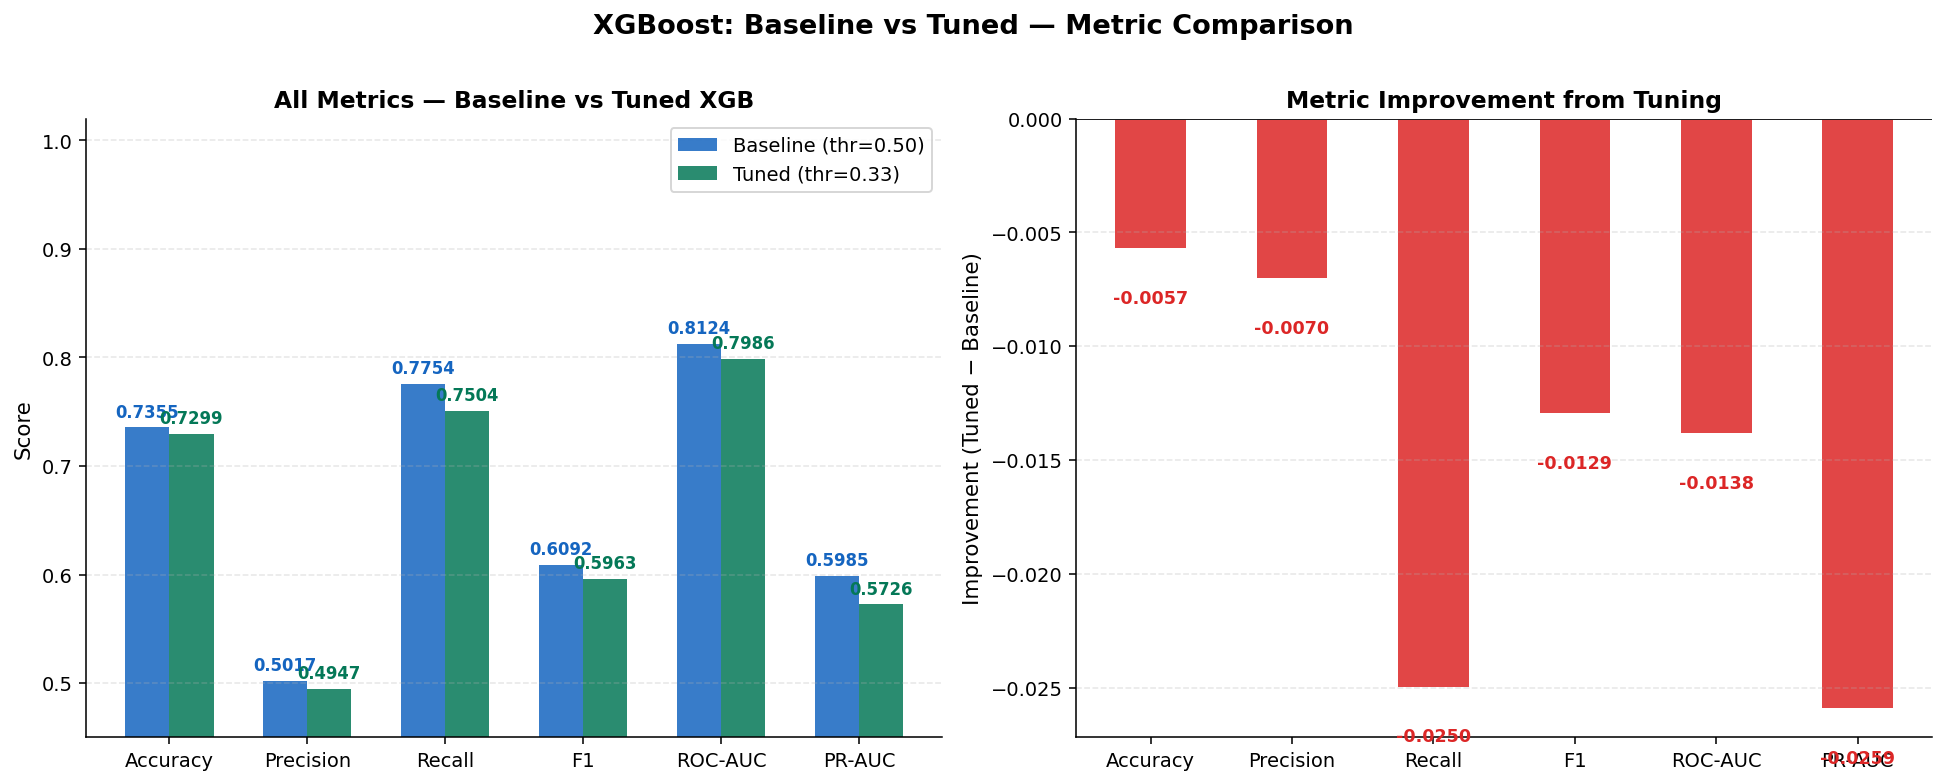

Saved: plots/rf_01_metrics_comparison.png


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: grouped bar chart ───────────────────────────────────────────────────
x     = np.arange(len(metrics_cols))
width = 0.32

bars_b = axes[0].bar(x - width/2, comparison['Baseline (thr=0.50)'],
                     width, color=C_BASE, alpha=0.85, label='Baseline (thr=0.50)')
bars_t = axes[0].bar(x + width/2, comparison['Tuned (thr=0.33)'],
                     width, color=C_TUNE, alpha=0.85, label='Tuned (thr=0.33)')

# Annotate values
for bars, col in [(bars_b, C_BASE), (bars_t, C_TUNE)]:
    for bar in bars:
        axes[0].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.006,
                     f'{bar.get_height():.4f}',
                     ha='center', va='bottom', fontsize=8.5,
                     color=col, fontweight='bold')

axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_cols, fontsize=10)
axes[0].set_ylim(0.45, 1.02)
axes[0].set_ylabel('Score')
axes[0].set_title('All Metrics — Baseline vs Tuned XGB', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3, linestyle='--')
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

# ── Right: improvement delta bar chart ───────────────────────────────────────
deltas = comparison['Improvement']
colours_delta = [C_TUNE if v >= 0 else '#DC2626' for v in deltas]

axes[1].bar(metrics_cols, deltas, color=colours_delta, alpha=0.85, width=0.5)
axes[1].axhline(0, color=C_DARK, linewidth=1)

for i, (metric, val) in enumerate(deltas.items()):
    axes[1].text(i, val + (0.0008 if val >= 0 else -0.0018),
                 f'{val:+.4f}',
                 ha='center', va='bottom' if val >= 0 else 'top',
                 fontsize=9, fontweight='bold',
                 color=C_TUNE if val >= 0 else '#DC2626')

axes[1].set_ylabel('Improvement (Tuned − Baseline)')
axes[1].set_title('Metric Improvement from Tuning', fontweight='bold')
axes[1].set_xticklabels(metrics_cols, fontsize=10)
axes[1].grid(axis='y', alpha=0.3, linestyle='--')
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

fig.suptitle('XGBoost: Baseline vs Tuned — Metric Comparison',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
# plt.savefig('plots/rf_01_metrics_comparison.png', bbox_inches='tight', dpi=150)
plt.show()
print("Saved: plots/rf_01_metrics_comparison.png")


### 5.3 CatBoost — Optuna Tuning

In [ ]:
def cat_objective(trial):
    """Optuna objective for CatBoost — uses manual CV to bypass sklearn clone issue."""
    params = {
        'iterations':          trial.suggest_int('iterations', 200, 1000, step=100),
        'learning_rate':       trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth':               trial.suggest_int('depth', 3, 10),
        'l2_leaf_reg':         trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0.0, 1.0),
        'random_strength':     trial.suggest_float('random_strength', 0.0, 1.0),
        'border_count':        trial.suggest_int('border_count', 32, 255),
        # ── FIX: cast to plain Python float so sklearn clone never touches it ──
        'class_weights':       [1.0, float(cat_scale_pw)],
        'loss_function':       'Logloss',
        'random_state':        RANDOM_STATE,
        'verbose':             False,
    }

    # ── Manual 5-fold CV (avoids cross_val_score's internal clone call) ──────
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    fold_scores = []

    for train_idx, val_idx in skf.split(X_train_smote, y_train_smote):
        X_tr  = X_train_smote.iloc[train_idx]
        X_val = X_train_smote.iloc[val_idx]
        y_tr  = y_train_smote.iloc[train_idx]
        y_val = y_train_smote.iloc[val_idx]

        model = CatBoostClassifier(**params)
        model.fit(X_tr, y_tr)

        y_pred = model.predict(X_val)
        fold_scores.append(f1_score(y_val, y_pred, zero_division=0))

    return np.mean(fold_scores)

print("Tuning CatBoost with Optuna (50 trials)...")
cat_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
cat_study.optimize(cat_objective, n_trials=50, show_progress_bar=True)

print(f"\n✅ CatBoost Best CV F1 = {cat_study.best_value:.4f}")
print("Best params:", cat_study.best_params)

Tuning CatBoost with Optuna (50 trials)...


Best trial: 21. Best value: 0.855515: 100%|██████████| 50/50 [36:12<00:00, 43.45s/it]


✅ CatBoost Best CV F1 = 0.8555
Best params: {'iterations': 600, 'learning_rate': 0.04410618997384899, 'depth': 10, 'l2_leaf_reg': 0.039552923862035495, 'bagging_temperature': 0.8783040020629514, 'random_strength': 0.4390732144208412, 'border_count': 223}


In [ ]:
cat_best = CatBoostClassifier(
    **cat_study.best_params,
    class_weights=[1.0, cat_scale_pw],
    loss_function='Logloss',
    random_state=RANDOM_STATE,
    verbose=False
)
cat_best.fit(X_train_smote, y_train_smote)

cat_prob = cat_best.predict_proba(X_test)[:, 1]
best_thr_cat_tuned, _ = find_best_threshold(y_test, cat_prob)

metrics_cat = full_evaluate('CatBoost (Tuned)', y_test, cat_prob, best_thr_cat_tuned)
all_results['CatBoost'] = metrics_cat
all_probs['CatBoost'] = cat_prob

print(f"CatBoost Tuned — best threshold: {best_thr_cat_tuned:.2f}")
print(classification_report(y_test, (cat_prob >= best_thr_cat_tuned).astype(int),
                              target_names=['No Churn', 'Churn'], digits=4))

CatBoost Tuned — best threshold: 0.40
              precision    recall  f1-score   support

    No Churn     0.8795    0.7495    0.8093      1549
       Churn     0.5089    0.7166    0.5951       561

    accuracy                         0.7408      2110
   macro avg     0.6942    0.7330    0.7022      2110
weighted avg     0.7810    0.7408    0.7524      2110



In [ ]:
print(classification_report(y_test, (cat_prob >= 0.5).astype(int),
                              target_names=['No Churn', 'Churn'], digits=4))

              precision    recall  f1-score   support

    No Churn     0.8679    0.7805    0.8219      1549
       Churn     0.5258    0.6720    0.5900       561

    accuracy                         0.7517      2110
   macro avg     0.6969    0.7263    0.7059      2110
weighted avg     0.7770    0.7517    0.7602      2110



## 6. Model Comparison

### 6.1 Metrics Comparison Table

In [ ]:
metrics_df = pd.DataFrame(all_results).T
display_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']

print("\n" + "="*70)
print("MODEL COMPARISON (Tuned models, optimal threshold per model)")
print("="*70)
print(metrics_df[display_cols].round(4).to_string())

# Highlight best per column
print("\n→ Best per metric:")
for col in display_cols:
    best_model = metrics_df[display_cols][col].idxmax()
    print(f"   {col:12s}: {best_model} ({metrics_df.loc[best_model, col]:.4f})")


MODEL COMPARISON (Tuned models, optimal threshold per model)
               Accuracy Precision    Recall        F1   ROC-AUC    PR-AUC
Random Forest  0.743602  0.511933  0.764706  0.613295  0.813413  0.584076
XGBoost        0.729858  0.494712  0.750446  0.596317  0.798568  0.572579
CatBoost       0.740758  0.508861  0.716578  0.595115  0.803789  0.580788

→ Best per metric:
   Accuracy    : Random Forest (0.7436)
   Precision   : Random Forest (0.5119)
   Recall      : Random Forest (0.7647)
   F1          : Random Forest (0.6133)
   ROC-AUC     : Random Forest (0.8134)
   PR-AUC      : Random Forest (0.5841)


### 6.2 Bar Chart Comparison

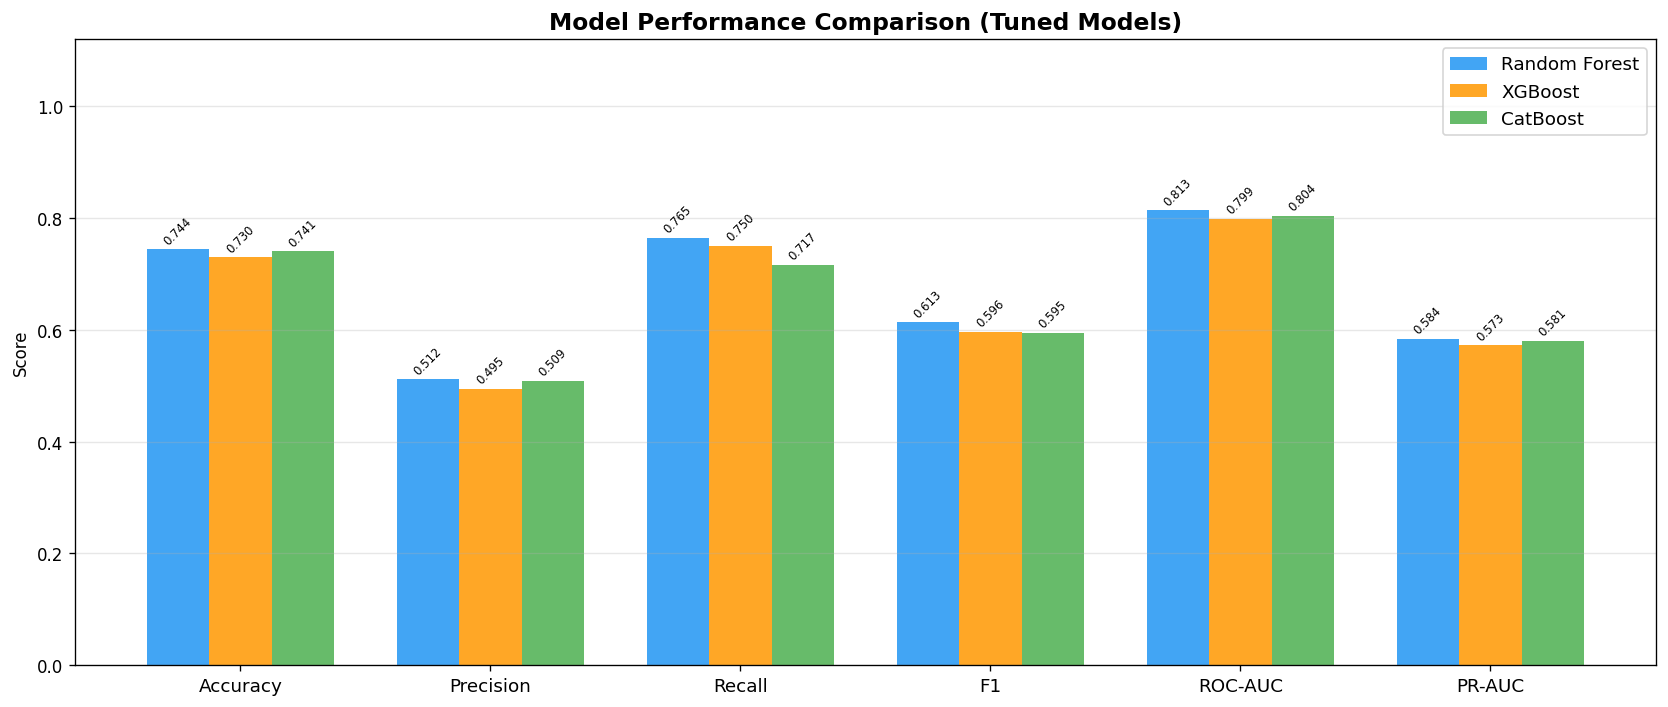

In [ ]:
metrics_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC']
models = list(all_results.keys())
x = np.arange(len(metrics_plot))
width = 0.25
colours = ['#2196F3', '#FF9800', '#4CAF50']

fig, ax = plt.subplots(figsize=(14, 6))
for i, (model, colour) in enumerate(zip(models, colours)):
    vals = [all_results[model][m] for m in metrics_plot]
    bars = ax.bar(x + i * width, vals, width, label=model, color=colour, alpha=0.85)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.004,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics_plot, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison (Tuned Models)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
# plt.savefig('plots/10_model_comparison.png', bbox_inches='tight')
plt.show()

### 6.3 ROC Curves

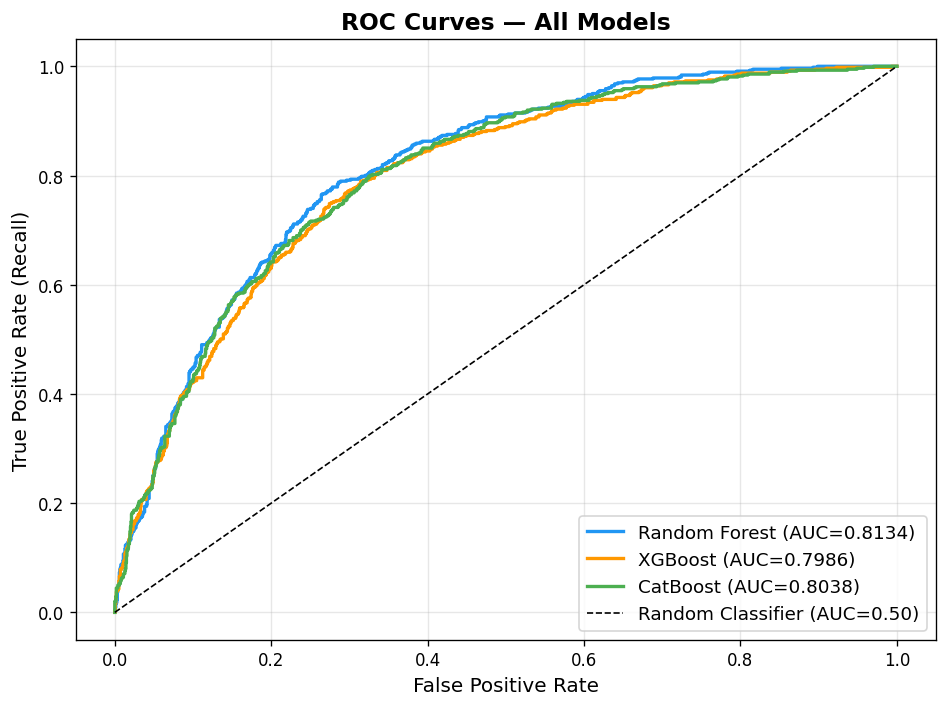

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

colours = {'Random Forest': '#2196F3', 'XGBoost': '#FF9800', 'CatBoost': '#4CAF50'}

for model_name, y_prob in all_probs.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = all_results[model_name]['ROC-AUC']
    ax.plot(fpr, tpr, label=f'{model_name} (AUC={auc:.4f})',
            color=colours[model_name], lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier (AUC=0.50)')
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('plots/11_roc_curves.png', bbox_inches='tight')
plt.show()

### 6.4 Precision-Recall Curves

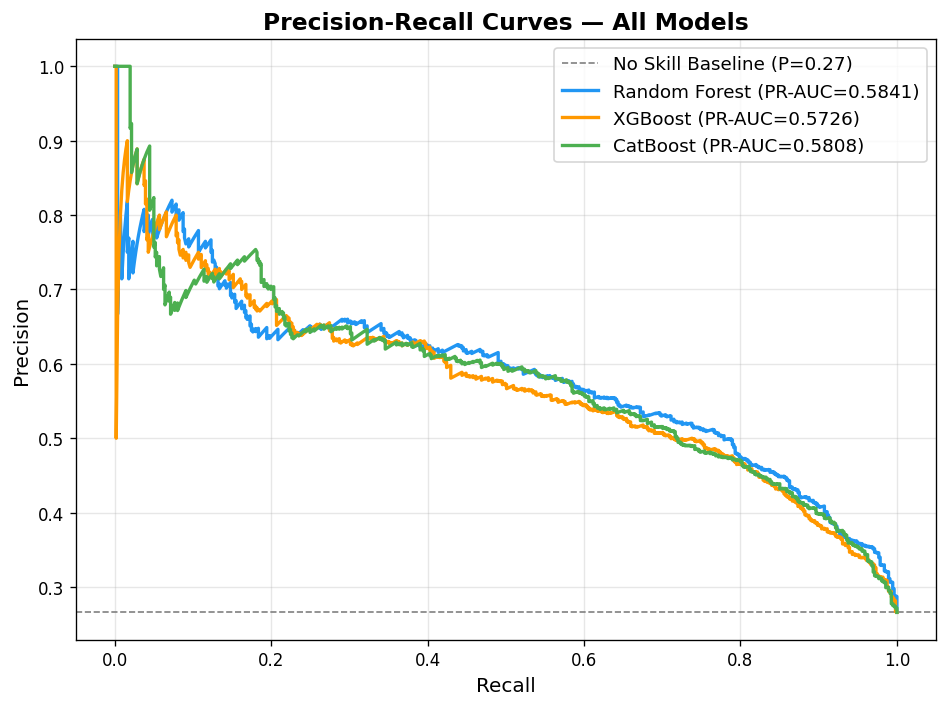

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

baseline_pr = y_test.mean()   # no-skill PR-AUC = churn rate
ax.axhline(baseline_pr, color='grey', linestyle='--', lw=1,
           label=f'No Skill Baseline (P={baseline_pr:.2f})')

for model_name, y_prob in all_probs.items():
    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    pr_auc = all_results[model_name]['PR-AUC']
    ax.plot(recall, precision, label=f'{model_name} (PR-AUC={pr_auc:.4f})',
            color=colours[model_name], lw=2)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
# plt.savefig('plots/12_pr_curves.png', bbox_inches='tight')
plt.show()

### 6.5 Confusion Matrices

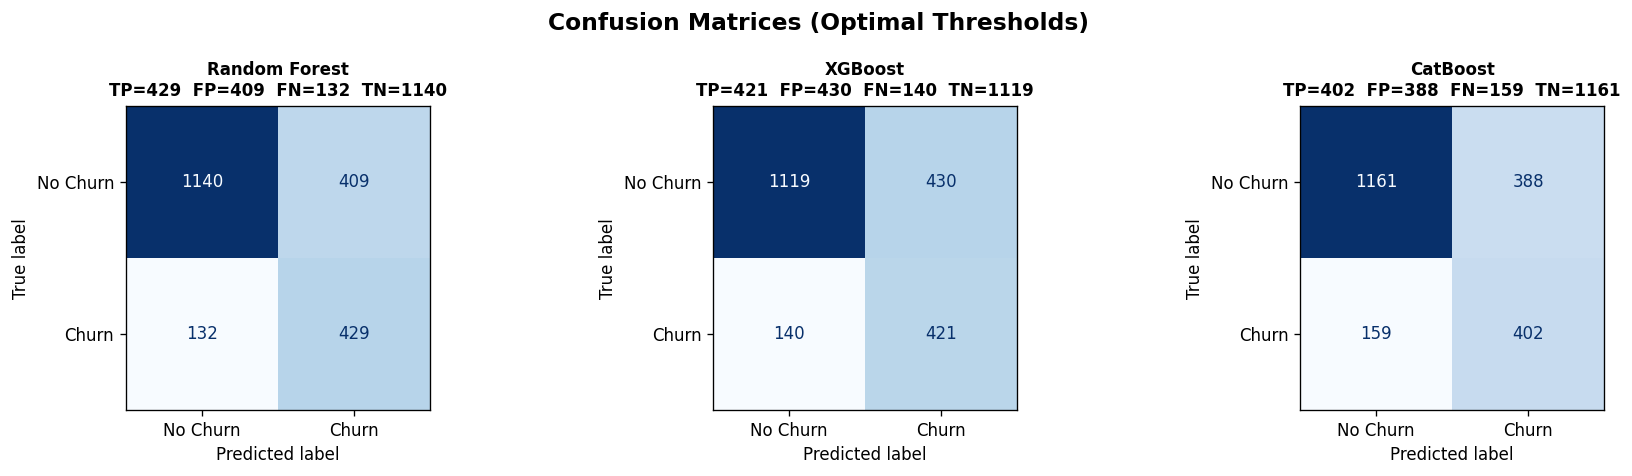

In [ ]:
thresholds_used = {
    'Random Forest': best_thr_rf_tuned,
    'XGBoost': best_thr_xgb_tuned,
    'CatBoost': best_thr_cat_tuned,
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (model_name, y_prob) in zip(axes, all_probs.items()):
    thr = thresholds_used[model_name]
    y_pred = (y_prob >= thr).astype(int)
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                            display_labels=['No Churn', 'Churn']).plot(
        ax=ax, colorbar=False, cmap='Blues')
    tn, fp, fn, tp = cm.ravel()
    ax.set_title(f'{model_name}\n'
                 f'TP={tp}  FP={fp}  FN={fn}  TN={tn}',
                 fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices (Optimal Thresholds)', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('plots/13_confusion_matrices.png', bbox_inches='tight')
plt.show()

## 7. Feature Importance Analysis

We analyse the best-performing model in detail to understand which features drive churn predictions.

In [ ]:
# Determine best model by F1 
best_model_name = max(all_results, key=lambda k: all_results[k]['F1'])
print(f"Best model by F1: {best_model_name} (F1={all_results[best_model_name]['F1']:.4f})")

# Map to model object
model_objects = {
    'Random Forest': rf_best,
    'XGBoost': xgb_best,
    'CatBoost': cat_best,
}
best_model_obj = model_objects[best_model_name]
feature_names = X_test.columns.tolist()

Best model by F1: Random Forest (F1=0.6133)


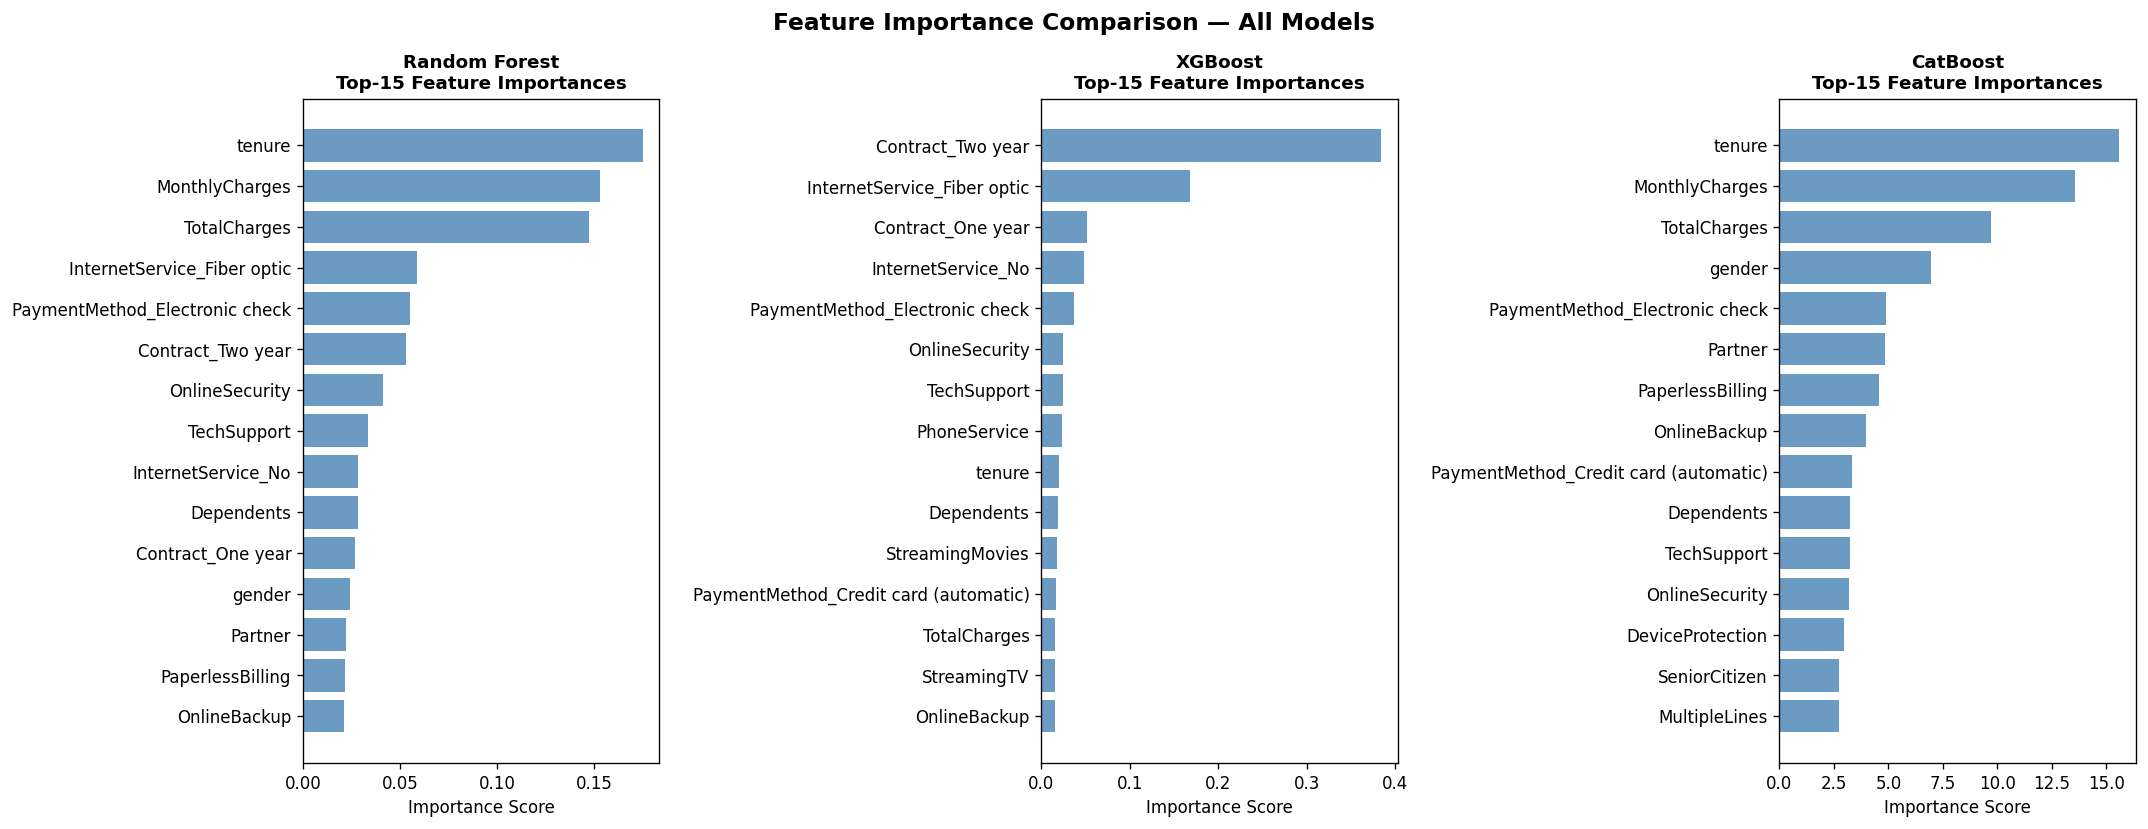

In [ ]:
# Feature importances from all three models
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, (name, model) in zip(axes, model_objects.items()):
    importances = model.feature_importances_
    fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    fi_df = fi_df.sort_values('Importance', ascending=True).tail(15)

    ax.barh(fi_df['Feature'], fi_df['Importance'], color='steelblue', alpha=0.8)
    ax.set_title(f'{name}\nTop-15 Feature Importances', fontweight='bold', fontsize=11)
    ax.set_xlabel('Importance Score')

plt.suptitle('Feature Importance Comparison — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('plots/14_feature_importances.png', bbox_inches='tight')
plt.show()

Top 15 Features — Random Forest:

                       Feature  Importance
                        tenure    0.174750
                MonthlyCharges    0.153032
                  TotalCharges    0.147173
   InternetService_Fiber optic    0.058838
PaymentMethod_Electronic check    0.055191
             Contract_Two year    0.053137
                OnlineSecurity    0.041081
                   TechSupport    0.033468
            InternetService_No    0.028314
                    Dependents    0.028284
             Contract_One year    0.026958
                        gender    0.023981
                       Partner    0.022092
              PaperlessBilling    0.021480
                  OnlineBackup    0.021046


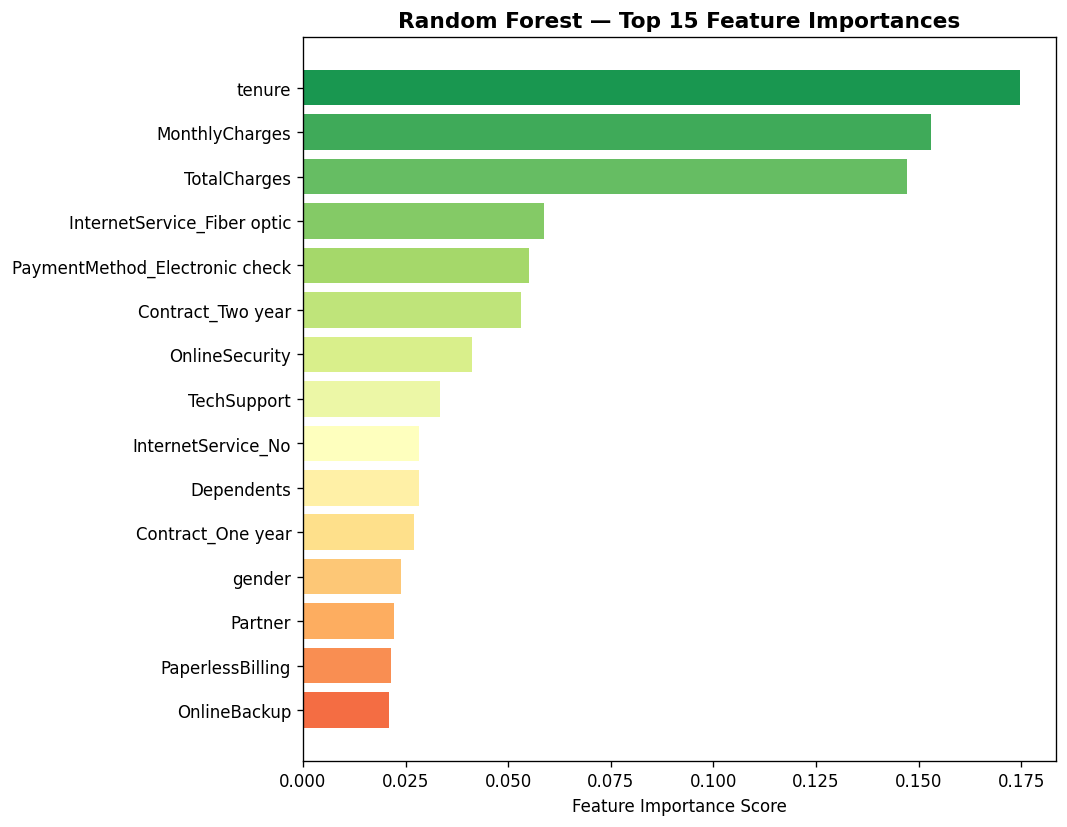

In [ ]:
# Best model — detailed feature importance with interpretation
importances = best_model_obj.feature_importances_
fi_df = (pd.DataFrame({'Feature': feature_names, 'Importance': importances})
           .sort_values('Importance', ascending=False))

print(f"Top 15 Features — {best_model_name}:\n")
print(fi_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 7))
top15 = fi_df.head(15).sort_values('Importance')
colours_fi = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(top15)))
ax.barh(top15['Feature'], top15['Importance'], color=colours_fi)
ax.set_title(f'{best_model_name} — Top 15 Feature Importances', fontweight='bold')
ax.set_xlabel('Feature Importance Score')
plt.tight_layout()
# plt.savefig('plots/15_best_model_feature_importance.png', bbox_inches='tight')
plt.show()

## 8. Optuna Tuning Visualisation

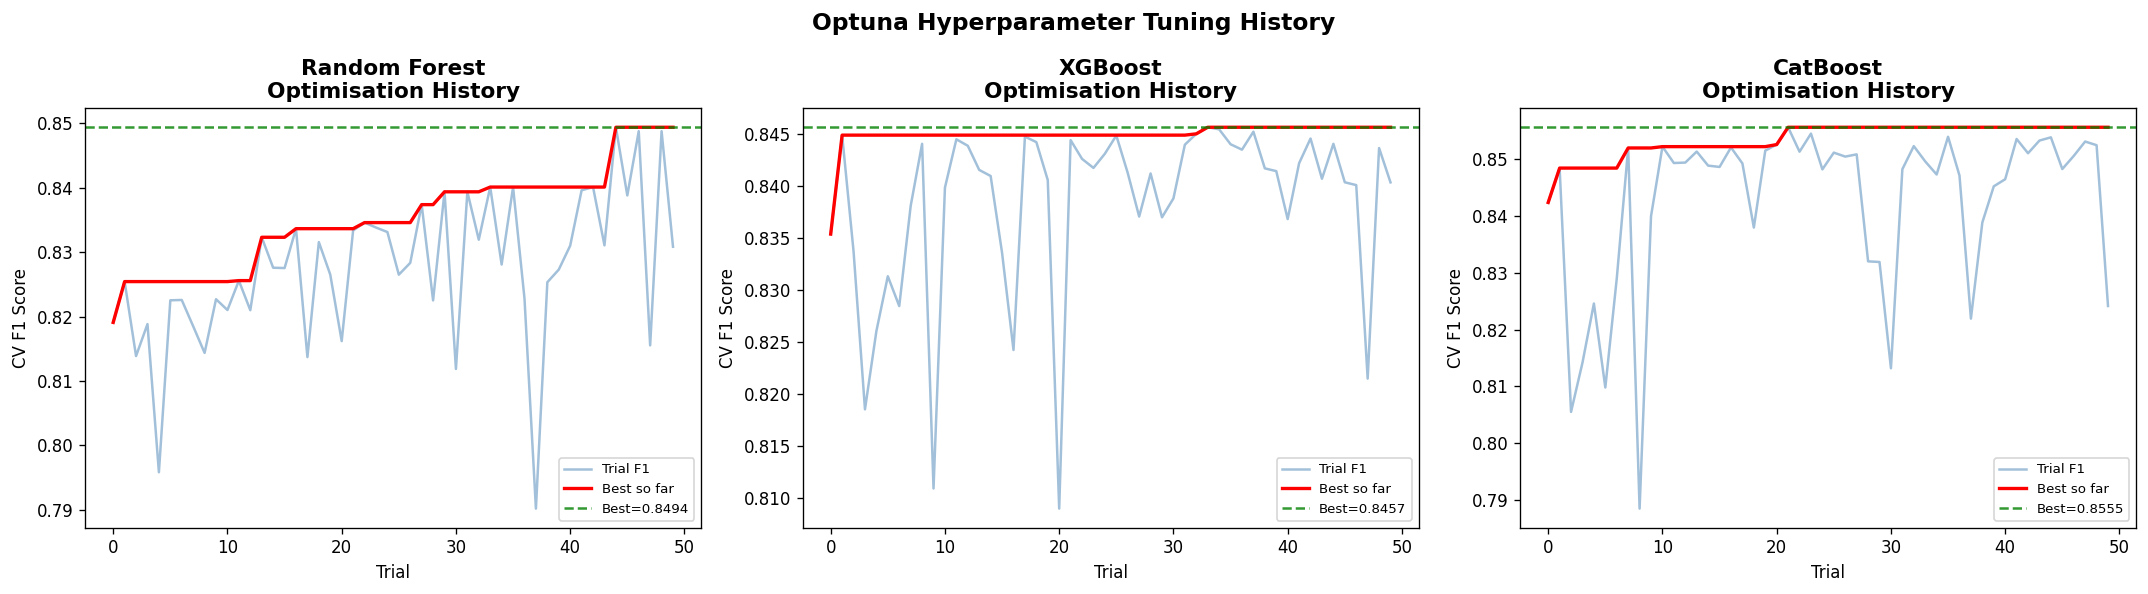

In [ ]:
# Optuna optimisation history 
study_map = {'Random Forest': rf_study, 'XGBoost': xgb_study, 'CatBoost': cat_study}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, study) in zip(axes, study_map.items()):
    trial_vals = [t.value for t in study.trials]
    best_vals  = np.maximum.accumulate(trial_vals)
    ax.plot(trial_vals, alpha=0.5, color='steelblue', label='Trial F1')
    ax.plot(best_vals, color='red', lw=2, label='Best so far')
    ax.axhline(study.best_value, linestyle='--', color='green', alpha=0.8,
               label=f'Best={study.best_value:.4f}')
    ax.set_title(f'{name}\nOptimisation History', fontweight='bold')
    ax.set_xlabel('Trial'); ax.set_ylabel('CV F1 Score')
    ax.legend(fontsize=8)

plt.suptitle('Optuna Hyperparameter Tuning History', fontsize=14, fontweight='bold')
plt.tight_layout()
# plt.savefig('plots/16_optuna_history.png', bbox_inches='tight')
plt.show()

## 9. Final Summary

In [ ]:
print("=" * 70)
print("FINAL MODEL PERFORMANCE SUMMARY (Tuned, Optimal Thresholds)")
print("=" * 70)

final_df = pd.DataFrame(all_results).T[
    ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'PR-AUC', 'Threshold']
].round(4)

print(final_df.to_string())

print("\n" + "=" * 70)
print("BEST MODEL:", best_model_name)
print(f"  F1       = {all_results[best_model_name]['F1']:.4f}")
print(f"  Recall   = {all_results[best_model_name]['Recall']:.4f}")
print(f"  ROC-AUC  = {all_results[best_model_name]['ROC-AUC']:.4f}")
print(f"  PR-AUC   = {all_results[best_model_name]['PR-AUC']:.4f}")
print("=" * 70)

# Business interpretation 
cm_best = confusion_matrix(y_test,
    (all_probs[best_model_name] >= thresholds_used[best_model_name]).astype(int))
tn, fp, fn, tp = cm_best.ravel()

print("\nBusiness Interpretation on Test Set:")
print(f"  True Positives  (correctly identified churners):   {tp:,}")
print(f"  False Negatives (missed churners — costly!):       {fn:,}")
print(f"  False Positives (unnecessary retention offers):    {fp:,}")
print(f"  True Negatives  (correctly identified loyals):     {tn:,}")
print(f"\n  Churn Capture Rate (Recall): {tp/(tp+fn)*100:.1f}%  — "
      f"i.e. {tp/(tp+fn)*100:.1f}% of at-risk customers would receive a retention offer.")

FINAL MODEL PERFORMANCE SUMMARY (Tuned, Optimal Thresholds)
               Accuracy Precision    Recall        F1   ROC-AUC    PR-AUC Threshold
Random Forest  0.743602  0.511933  0.764706  0.613295  0.813413  0.584076       0.4
XGBoost        0.729858  0.494712  0.750446  0.596317  0.798568  0.572579      0.33
CatBoost       0.740758  0.508861  0.716578  0.595115  0.803789  0.580788       0.4

BEST MODEL: Random Forest
  F1       = 0.6133
  Recall   = 0.7647
  ROC-AUC  = 0.8134
  PR-AUC   = 0.5841

Business Interpretation on Test Set:
  True Positives  (correctly identified churners):   429
  False Negatives (missed churners — costly!):       132
  False Positives (unnecessary retention offers):    409
  True Negatives  (correctly identified loyals):     1,140

  Churn Capture Rate (Recall): 76.5%  — i.e. 76.5% of at-risk customers would receive a retention offer.
